## Imports and Setup
We'll use torch and torchvision. We also define the computation device (GPU/CPU).

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import functools
from torch.optim import Adam
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# Use GPU if available
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


## Data Preparation (Filtering '1's and '8's)
Here we load MNIST and strictly filter the dataset to only contain the bimodal distribution of digits "1" and "8".

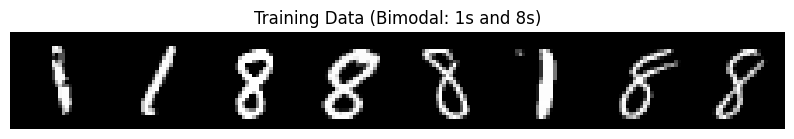

In [ ]:
# Configuration
BATCH_SIZE = 64
IMG_SIZE = 28

# Load MNIST
dataset = MNIST('.', train=True, transform=transforms.ToTensor(), download=True)

# Filter for only 1s and 8s
idx = (dataset.targets == 1) | (dataset.targets == 8)
dataset.targets = dataset.targets[idx]
dataset.data = dataset.data[idx]

data_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

# Visualize a few real samples to verify
real_batch = next(iter(data_loader))[0]
plt.figure(figsize=(10, 2))
plt.axis('off')
plt.title("Training Data (Bimodal: 1s and 8s)")
plt.imshow(torch.cat([real_batch[i] for i in range(8)], dim=2).squeeze().numpy(), cmap='gray')
plt.show()

## The SDE Utils (Perturbation Kernel)

We define the Variance Exploding SDE.Forward Process: We smear the data by adding Gaussian noise with increasing standard deviation $\sigma(t)$.Transition Kernel: The probability $p_{0t}(x(t) | x(0))$ is a Gaussian centered at $x(0)$ with variance $\sigma(t)^2 - \sigma(0)^2$.

In [ ]:
# SDE Hyperparameters
sigma_min = 0.01  # Minimum noise level
sigma_max = 50.0  # Maximum noise level

def marginal_prob_std(t, sigma_min, sigma_max):
    """Compute the standard deviation of the perturbation kernel p_{0t}(x(t) | x(0))."""
    # We use a geometric progression of noise levels (VE-SDE)
    # sigma(t) = sigma_min * (sigma_max / sigma_min)^t
    # The 't' passed here is already a tensor, so no conversion is needed.
    return sigma_min * (sigma_max / sigma_min) ** t

def diffusion_coeff(t, sigma_min, sigma_max):
    """Compute the diffusion coefficient g(t) for the SDE."""
    # For VE-SDE: g(t) = sigma(t) * sqrt(2 * log(sigma_max/sigma_min))
    sigma = marginal_prob_std(t, sigma_min, sigma_max)
    return sigma * np.sqrt(2 * (np.log(sigma_max) - np.log(sigma_min)))

## The Score Network (U-Net with Time Embeddings)We need a neural network
$s_\theta(x, t)$ that predicts the "score" (the gradient of the log-probability density). Since 1$t$ is continuous, we inject it using Gaussian Fourier Embeddings (similar to the Positional Encodings you might see in Transformer architectures).2

In [ ]:
class GaussianFourierProjection(nn.Module):
    """Gaussian random features for encoding time steps."""
    def __init__(self, embed_dim, scale=30.):
        super().__init__()
        # Randomly sampled weights (fixed during training)
        self.W = nn.Parameter(torch.randn(embed_dim // 2) * scale, requires_grad=False)
    def forward(self, x):
        x_proj = x[:, None] * self.W[None, :] * 2 * np.pi
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)

class ScoreNet(nn.Module):
    """A simple U-Net-like architecture for estimating scores."""
    def __init__(self, marginal_prob_std_func, channels=[32, 64, 128, 256], embed_dim=256):
        super().__init__()
        self.embed = nn.Sequential(GaussianFourierProjection(embed_dim=embed_dim),
             nn.Linear(embed_dim, embed_dim))

        # Encoding layers
        self.conv1 = nn.Conv2d(1, channels[0], 3, stride=1, padding=1)
        self.dense1 = nn.Linear(embed_dim, channels[0])
        self.gnorm1 = nn.GroupNorm(4, num_channels=channels[0])

        self.conv2 = nn.Conv2d(channels[0], channels[1], 3, stride=2, padding=1)
        self.dense2 = nn.Linear(embed_dim, channels[1])
        self.gnorm2 = nn.GroupNorm(32, num_channels=channels[1])

        self.conv3 = nn.Conv2d(channels[1], channels[2], 3, stride=2, padding=1)
        self.dense3 = nn.Linear(embed_dim, channels[2])
        self.gnorm3 = nn.GroupNorm(32, num_channels=channels[2])

        # Decoding layers
        self.tconv3 = nn.ConvTranspose2d(channels[2], channels[1], 3, stride=2, padding=1, output_padding=1)
        self.dense4 = nn.Linear(embed_dim, channels[1])
        self.tgnorm3 = nn.GroupNorm(32, num_channels=channels[1])

        self.tconv2 = nn.ConvTranspose2d(channels[1] + channels[1], channels[0], 3, stride=2, padding=1, output_padding=1)
        self.dense5 = nn.Linear(embed_dim, channels[0])
        self.tgnorm2 = nn.GroupNorm(32, num_channels=channels[0])

        self.tconv1 = nn.ConvTranspose2d(channels[0] + channels[0], 1, 3, stride=1, padding=1)

        self.act = nn.SiLU() # Swish activation
        self.marginal_prob_std = marginal_prob_std_func

    def forward(self, x, t):
        # Embed time
        embed = self.act(self.embed(t))

        # Encoder
        h1 = self.conv1(x)
        h1 += self.dense1(embed)[:, :, None, None] # Time injection
        h1 = self.act(self.gnorm1(h1))

        h2 = self.conv2(h1)
        h2 += self.dense2(embed)[:, :, None, None]
        h2 = self.act(self.gnorm2(h2))

        h3 = self.conv3(h2)
        h3 += self.dense3(embed)[:, :, None, None]
        h3 = self.act(self.gnorm3(h3))

        # Decoder (with Skip Connections)
        h = self.tconv3(h3)
        h += self.dense4(embed)[:, :, None, None]
        h = self.act(self.tgnorm3(h))

        h = self.tconv2(torch.cat([h, h2], dim=1)) # Skip from h2
        h += self.dense5(embed)[:, :, None, None]
        h = self.act(self.tgnorm2(h))

        h = self.tconv1(torch.cat([h, h1], dim=1)) # Skip from h1

        # Normalize output by marginal std (Score Scaling)
        h = h / self.marginal_prob_std(t)[:, None, None, None]
        return h

## The Loss Function
We use Denoising Score Matching. The objective is to make the network predict the noise $z$ that was added to the image.$$\text{Loss} = \mathbb{E} \left[ || s_\theta(x(t), t) \cdot \sigma(t) + z ||^2 \right]$$

In [ ]:
def loss_fn(model, x, marginal_prob_std, eps=1e-5):
    # Sample time uniformly in [eps, 1]
    random_t = torch.rand(x.shape[0], device=x.device) * (1. - eps) + eps

    # Find the noise std at this time
    std = marginal_prob_std(random_t, sigma_min, sigma_max)

    # Sample random noise z
    z = torch.randn_like(x)

    # Perturb the data: x(t) = x(0) + z * std
    perturbed_x = x + z * std[:, None, None, None]

    # Predict the score
    score = model(perturbed_x, random_t)

    # Loss: || score * std + z ||^2
    # Note: score * std should approximate -z
    loss = torch.mean(torch.sum((score * std[:, None, None, None] + z)**2, dim=(1,2,3)))
    return loss

## Training Loop
We will train the score network. This might take 2-5 minutes on a standard Colab GPU

In [ ]:
score_model = ScoreNet(marginal_prob_std_func=functools.partial(marginal_prob_std, sigma_min=sigma_min, sigma_max=sigma_max))
score_model = score_model.to(device)

n_epochs = 5000 # Train for enough epochs to see clear digits
optimizer = Adam(score_model.parameters(), lr=1e-4)

tqdm_epoch = tqdm(range(n_epochs))
for epoch in tqdm_epoch:
    avg_loss = 0.
    num_items = 0
    for x, y in data_loader:
        x = x.to(device)
        loss = loss_fn(score_model, x, marginal_prob_std)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        avg_loss += loss.item() * x.shape[0]
        num_items += x.shape[0]
    tqdm_epoch.set_description(f"Average Loss: {avg_loss / num_items:5f}")

  0%|          | 0/5000 [00:00<?, ?it/s]

## The Sampler (Euler-Maruyama)
To generate images, we solve the reverse-time SDE using the Euler-Maruyama numerical solver.$$dx = [f(x, t) - g^2(t) s_\theta(x, t)] dt + g(t) dw$$

In [ ]:
def euler_maruyama_sampler(score_model, marginal_prob_std, diffusion_coeff, batch_size=64, num_steps=500, device='cuda'):
    # 1. Initialize with random noise (Prior Distribution)
    # At t=T, the data is indistinguishable from Gaussian noise with std=sigma_max
    t = torch.ones(batch_size, device=device)
    init_x = torch.randn(batch_size, 1, 28, 28, device=device) * marginal_prob_std(t)[:, None, None, None]

    time_steps = torch.linspace(1., 1e-3, num_steps, device=device)
    step_size = time_steps[0] - time_steps[1]
    x = init_x

    with torch.no_grad():
        for time_step in tqdm(time_steps):
            batch_time_step = torch.ones(batch_size, device=device) * time_step

            # Calculate the drift and diffusion terms
            g = diffusion_coeff(batch_time_step)
            mean_x = x + (g**2)[:, None, None, None] * score_model(x, batch_time_step) * step_size

            # Add the stochastic noise term (only if not the last step)
            x = mean_x + torch.sqrt(step_size) * g[:, None, None, None] * torch.randn_like(x)

    # Normalize to [0, 1] for display
    return mean_x

## Visualization
Finally, let's generate the "1s" and "8s" from pure noise.

  0%|          | 0/500 [00:00<?, ?it/s]

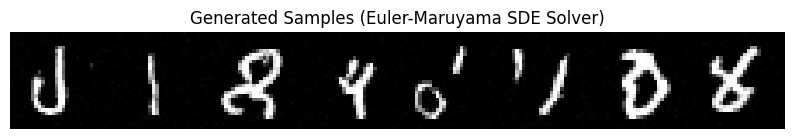

In [ ]:
# Generate samples
ckpt_path = 'score_model.pth'
torch.save(score_model.state_dict(), ckpt_path)

samples = euler_maruyama_sampler(score_model,
                                 functools.partial(marginal_prob_std, sigma_min=sigma_min, sigma_max=sigma_max),
                                 functools.partial(diffusion_coeff, sigma_min=sigma_min, sigma_max=sigma_max),
                                 batch_size=32,
                                 num_steps=500,
                                 device=device)

# Plotting
samples = samples.clamp(0.0, 1.0)
sample_grid = torch.cat([samples[i] for i in range(8)], dim=2).cpu().numpy().squeeze()

plt.figure(figsize=(10, 4))
plt.axis('off')
plt.title("Generated Samples (Euler-Maruyama SDE Solver)")
plt.imshow(sample_grid, cmap='gray')
plt.show()